In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

# Define paths to dataset
covid_dir = '../dataset/COVID/images'
normal_dir = '../dataset/Normal/images'

# Define image size and categories
IMG_SIZE = (224, 224)
CATEGORIES = ["COVID", "NORMAL"]

# Function to load images
def load_images(directory, label):
    images = []
    labels = []
    for filename in os.listdir(directory):
        img_path = os.path.join(directory, filename)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Convert to grayscale
        if img is not None:
            img = cv2.resize(img, IMG_SIZE)  # Resize image
            images.append(img)
            labels.append(label)
    return images, labels

# Load images
covid_images, covid_labels = load_images(covid_dir, 0)
normal_images, normal_labels = load_images(normal_dir, 1)

# Combine datasets
X = np.array(covid_images + normal_images)
y = np.array(covid_labels + normal_labels)

# Normalize pixel values
X = X / 255.0  # Scale images to range [0,1]

# Reshape for CNN input
X = X.reshape(-1, 224, 224, 1)  # Adding channel dimension

# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")


Training samples: 11046, Testing samples: 2762


Class Distribution: {np.int64(0): np.int64(3616), np.int64(1): np.int64(10192)}


C:\Users\kvmit\AppData\Local\Temp\ipykernel_12320\1625545822.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["COVID", "NORMAL"], y=counts, palette="Blues")


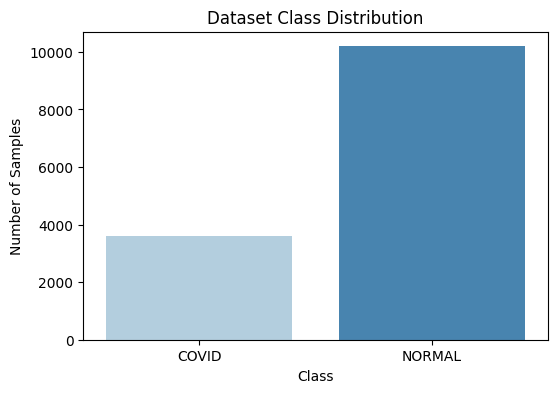

In [4]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Count class distribution
unique, counts = np.unique(y, return_counts=True)
class_distribution = dict(zip(unique, counts))

print("Class Distribution:", class_distribution)

# Plot the distribution
plt.figure(figsize=(6, 4))
sns.barplot(x=["COVID", "NORMAL"], y=counts, palette="Blues")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("Dataset Class Distribution")
plt.show()


In [5]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights
class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y), y=y)
class_weights_dict = {i: class_weights[i] for i in range(len(class_weights))}

print("Class Weights:", class_weights_dict)


Class Weights: {0: np.float64(1.9092920353982301), 1: np.float64(0.6773940345368917)}


In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Build CNN Model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')  # Binary classification (COVID=0, Normal=1)
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display model summary
model.summary()


d:\anaconda3\envs\lung_cancer\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,168,513 (42.60 MB)

 Trainable params: 11,168,513 (42.60 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights_dict  # Apply class weights
)


Epoch 1/10
346/346 ━━━━━━━━━━━━━━━━━━━━ 194s 555ms/step - accuracy: 0.7386 - loss: 0.5607 - val_accuracy: 0.8458 - val_loss: 0.3170
Epoch 2/10
346/346 ━━━━━━━━━━━━━━━━━━━━ 205s 592ms/step - accuracy: 0.8774 - loss: 0.2787 - val_accuracy: 0.8827 - val_loss: 0.2554
Epoch 3/10
346/346 ━━━━━━━━━━━━━━━━━━━━ 203s 588ms/step - accuracy: 0.9238 - loss: 0.1988 - val_accuracy: 0.9258 - val_loss: 0.1819
Epoch 4/10
346/346 ━━━━━━━━━━━━━━━━━━━━ 201s 581ms/step - accuracy: 0.9482 - loss: 0.1460 - val_accuracy: 0.9475 - val_loss: 0.1299
Epoch 5/10
346/346 ━━━━━━━━━━━━━━━━━━━━ 193s 559ms/step - accuracy: 0.9602 - loss: 0.1046 - val_accuracy: 0.9558 - val_loss: 0.1210
Epoch 6/10
346/346 ━━━━━━━━━━━━━━━━━━━━ 190s 549ms/step - accuracy: 0.9681 - loss: 0.0895 - val_accuracy: 0.9591 - val_loss: 0.1075
Epoch 7/10
346/346 ━━━━━━━━━━━━━━━━━━━━ 191s 551ms/step - accuracy: 0.9722 - loss: 0.0756 - val_accuracy: 0.9562 - val_loss: 0.1263
Epoch 8/10
346/346 ━━━━━━━━━━━━━━━━━━━━ 190s 548ms/step - accuracy: 0.9792 -

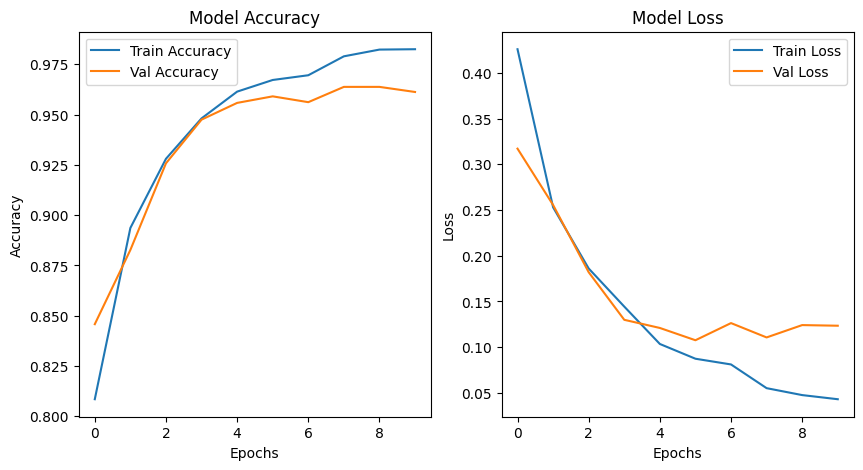

In [8]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')

# Plot training & validation loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')

plt.show()


87/87 ━━━━━━━━━━━━━━━━━━━━ 10s 119ms/step


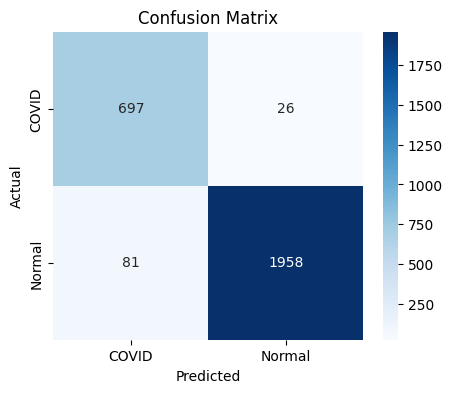

Classification Report:
               precision    recall  f1-score   support

       COVID       0.90      0.96      0.93       723
      Normal       0.99      0.96      0.97      2039

    accuracy                           0.96      2762
   macro avg       0.94      0.96      0.95      2762
weighted avg       0.96      0.96      0.96      2762



In [9]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# Make predictions
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)  # Convert probabilities to binary classes

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["COVID", "Normal"], yticklabels=["COVID", "Normal"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Print classification report
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=["COVID", "Normal"]))


In [ ]:
model.save("covid_detection_model.h5")
print("Model saved successfully!")

from tensorflow.keras.models import load_model
import cv2
import numpy as np




Model saved successfully!
Model loaded successfully!


In [30]:
def predict_image(img_path):
    try:
        img = preprocess_image(img_path)
        prediction = model.predict(img)[0][0]  # Get raw probability

        print(f"Raw Model Output: {prediction:.4f}")

        # Check threshold for classification
        predicted_class = "Covid" if prediction < 0.5 else "Normal"
        print(f"Predicted Class: {predicted_class}")

    except Exception as e:
        print(f"Error: {e}")

# Test with an X-ray image
image_paths = [
    r"D:\covid\dataset\COVID\images\Covid-3500.png",  # A COVID Image
    r"D:\covid\dataset\Normal\images\Normal-10000.png"  # A Normal Image
]

for path in image_paths:
    print(f"\nTesting Image: {path}")
    predict_image(path)
  # Update with actual path



Testing Image: D:\covid\dataset\COVID\images\Covid-3500.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Raw Model Output: 0.0000
Predicted Class: Covid

Testing Image: D:\covid\dataset\Normal\images\Normal-10000.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Raw Model Output: 0.9995
Predicted Class: Normal
